# Imports

In [1]:
import os


os.chdir("../")

In [10]:
from tensorflow.keras import models

import numpy as np

from matplotlib import pyplot as plt

from utils import (hyperas_path, init, load_cifar10, get_model, 
                get_callbacks, plot_history, get_dataset, 
                show_img, copy_model, save_samples, load_samples)


init()

TUNED_MODEL_PATH = os.path.join(hyperas_path, "cifar10_model_01.h5")
BATCH_SIZE = 128
EPOCHS = 100

# Demonstrating the usual 10-class training setting

## Hyperparameter-tuned Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10()

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



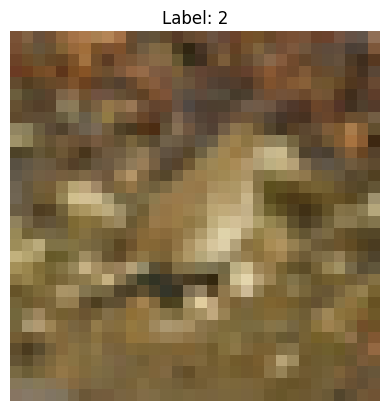

In [12]:
index = 1_000
show_img(x_train[index], y_train[index])

In [13]:
model = get_model(10, model_type="hp-tuned", model_path=TUNED_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 16, 16, 64)        9664      
                                                                 
 sequential_7 (Sequential)   (None, 8, 8, 128)         222208    
                                                                 
 sequential_8 (Sequential)   (None, 4, 4, 128)         295936    
                                                                 
 sequential_9 (Sequential)   (None, 2, 2, 256)         295936    
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                        

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 11s 23ms/step - loss: 1.4033 - accuracy: 0.4966 - val_loss: 2.6316 - val_accuracy: 0.2719
Epoch 2/100
313/313 [==============================] - 7s 21ms/step - loss: 0.9531 - accuracy: 0.6611 - val_loss: 1.5426 - val_accuracy: 0.5000
Epoch 3/100
313/313 [==============================] - 7s 21ms/step - loss: 0.7570 - accuracy: 0.7338 - val_loss: 1.0097 - val_accuracy: 0.6537
Epoch 4/100
313/313 [==============================] - 7s 21ms/step - loss: 0.6215 - accuracy: 0.7837 - val_loss: 0.9815 - val_accuracy: 0.6718
Epoch 5/100
313/313 [==============================] - 7s 21ms/step - loss: 0.5252 - accuracy: 0.8175 - val_loss: 0.9472 - val_accuracy: 0.6873
Epoch 6/100
313/313 [==============================] - 7s 21ms/step - loss: 0.4368 - accuracy: 0.8478 - val_loss: 0.9513 - val_accuracy: 0.6909
Epoch 7/100
313/313 [==============================] - 7s 21ms/step - loss: 0.3714 - accuracy: 0.8706 - val_loss: 1.0242 - val_accuracy

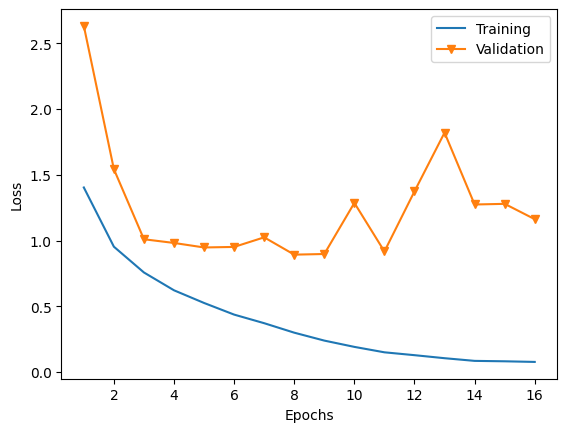

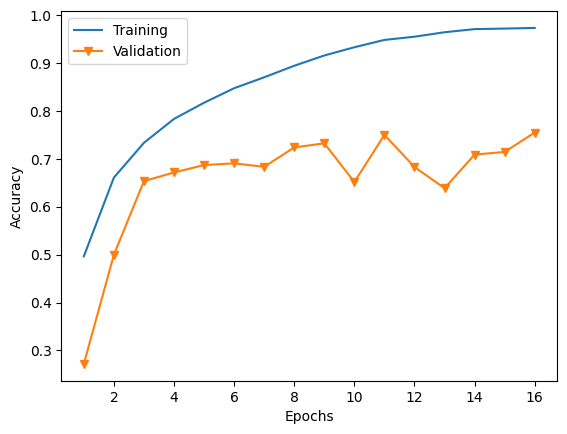

313/313 [==============================] - 1s 4ms/step - loss: 0.9191 - accuracy: 0.7528


[0.9191192388534546, 0.7527999877929688]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False, verbose=0)

In [12]:
conv_base = models.Sequential(get_model(10, model_type="pretrained", verbose=0).layers[:4])
conv_base.trainable = False

# trainset = get_dataset(x_train, y_train, conv_base=conv_base, batch_size=BATCH_SIZE)
# valset = get_dataset(x_val, y_val, conv_base=conv_base, batch_size=BATCH_SIZE)
# testset = get_dataset(x_test, y_test, conv_base=conv_base, batch_size=BATCH_SIZE)

feature_train = conv_base.predict(x_train, batch_size=BATCH_SIZE)
feature_val = conv_base.predict(x_val, batch_size=BATCH_SIZE)
feature_test = conv_base.predict(x_test, batch_size=BATCH_SIZE)

del conv_base

save_samples(
    np.array([feature_train, feature_val, feature_test], dtype="object"), 
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

79/79 [==============================] - 73s 940ms/step


In [ ]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [13]:
model = get_model(10, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                20490     
                                                                 
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
_________________________________________________________________


In [14]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 0.5361 - accuracy: 0.8285 - val_loss: 0.3863 - val_accuracy: 0.8721
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3932 - accuracy: 0.8654 - val_loss: 0.3503 - val_accuracy: 0.8823
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3732 - accuracy: 0.8723 - val_loss: 0.3413 - val_accuracy: 0.8801
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3636 - accuracy: 0.8747 - val_loss: 0.3416 - val_accuracy: 0.8793
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3554 - accuracy: 0.8781 - val_loss: 0.3305 - val_accuracy: 0.8827
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3528 - accuracy: 0.8779 - val_loss: 0.3327 - val_accuracy: 0.8833
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3501 - accuracy: 0.8789 - val_loss: 0.3277 - val_ac

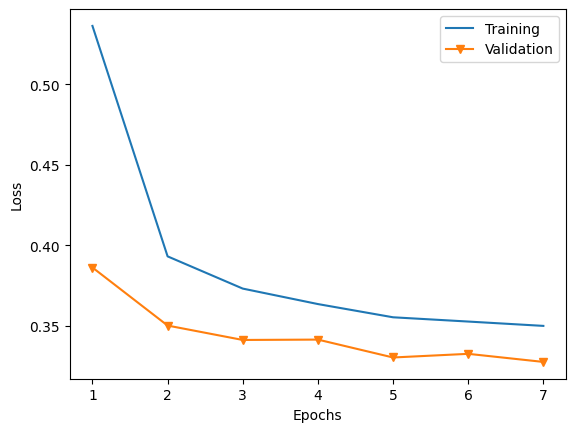

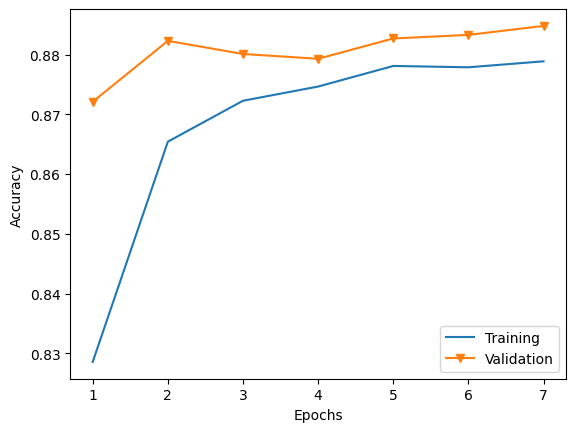

313/313 [==============================] - 1s 3ms/step - loss: 0.3587 - accuracy: 0.8788


[0.35869887471199036, 0.8787999749183655]

In [15]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False)

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



In [12]:
model = get_model(10, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 10)                2

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 804s 3s/step - loss: 0.3157 - accuracy: 0.8951 - val_loss: 0.2794 - val_accuracy: 0.9133
Epoch 2/100
313/313 [==============================] - 833s 3s/step - loss: 0.1676 - accuracy: 0.9423 - val_loss: 0.2581 - val_accuracy: 0.9157
Epoch 3/100
313/313 [==============================] - 666s 2s/step - loss: 0.1059 - accuracy: 0.9624 - val_loss: 0.2893 - val_accuracy: 0.9163
Epoch 4/100
313/313 [==============================] - 495s 2s/step - loss: 0.0650 - accuracy: 0.9777 - val_loss: 0.3214 - val_accuracy: 0.9159
Epoch 5/100
313/313 [==============================] - 828s 3s/step - loss: 0.0417 - accuracy: 0.9857 - val_loss: 0.2883 - val_accuracy: 0.9222
Epoch 6/100
313/313 [==============================] - 871s 3s/step - loss: 0.0360 - accuracy: 0.9877 - val_loss: 0.3195 - val_accuracy: 0.9259
Epoch 7/100
313/313 [==============================] - 681s 2s/step - loss: 0.0318 - accuracy: 0.9886 - val_loss: 0.3426 - val_accuracy:

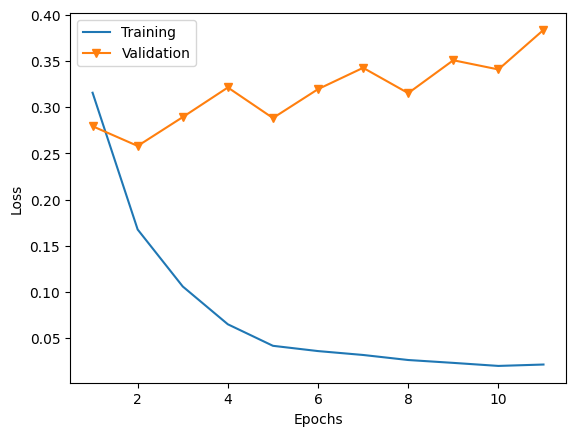

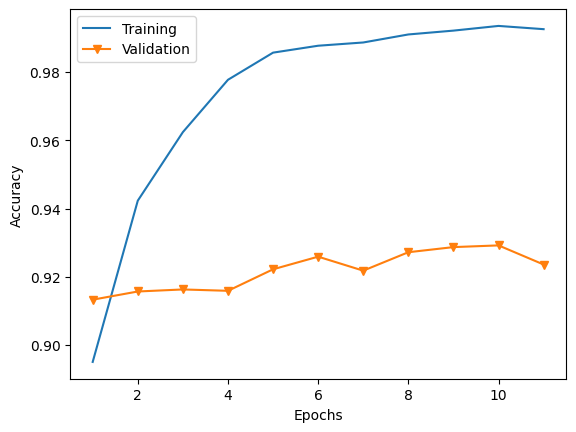

313/313 [==============================] - 159s 488ms/step - loss: 0.3389 - accuracy: 0.9225


[0.338937371969223, 0.9225000143051147]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continually adding classes to different models

---Classes [0, 1]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


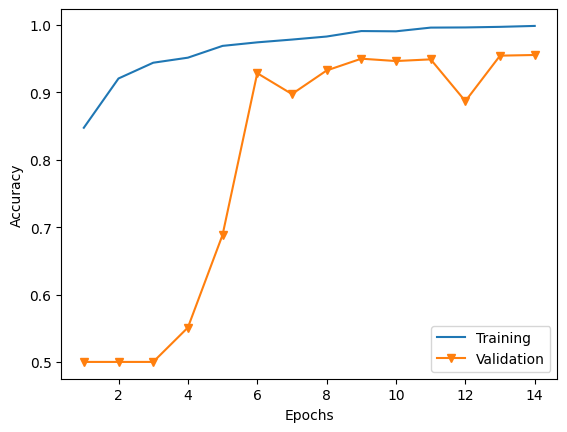

63/63 [==============================] - 0s 4ms/step - loss: 0.1364 - accuracy: 0.9515

---Classes [0, 1, 2]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


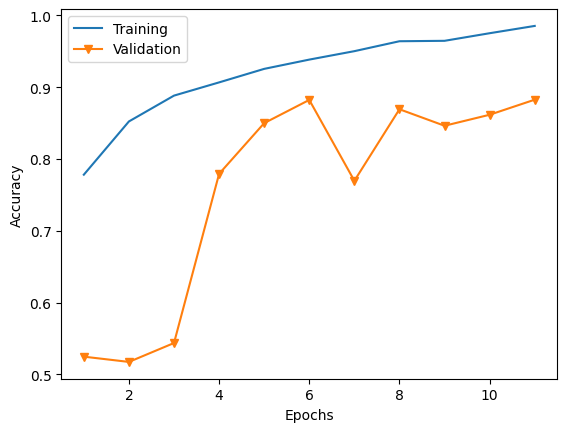

94/94 [==============================] - 0s 5ms/step - loss: 0.3243 - accuracy: 0.8753

---Classes [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


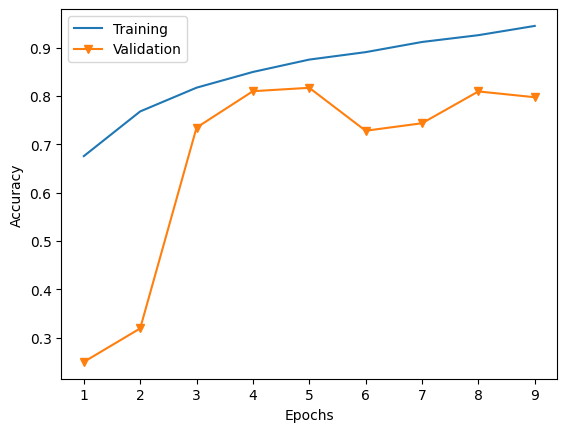

125/125 [==============================] - 1s 4ms/step - loss: 0.4961 - accuracy: 0.8008

---Classes [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 17.
Epoch 22: early stopping


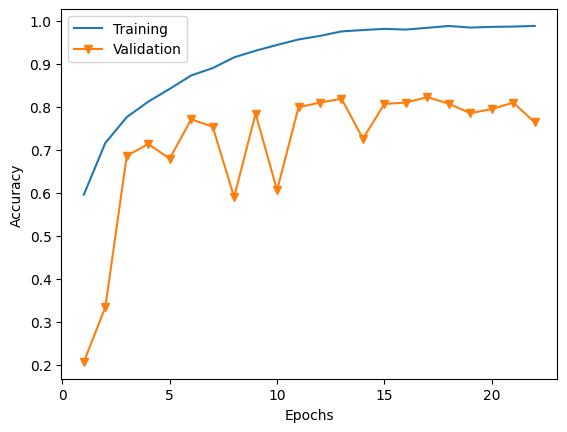

157/157 [==============================] - 1s 4ms/step - loss: 0.7612 - accuracy: 0.8116

---Classes [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


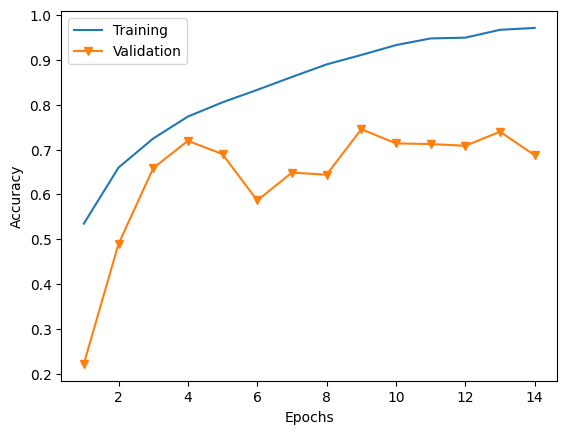

188/188 [==============================] - 1s 4ms/step - loss: 0.7670 - accuracy: 0.7427

---Classes [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


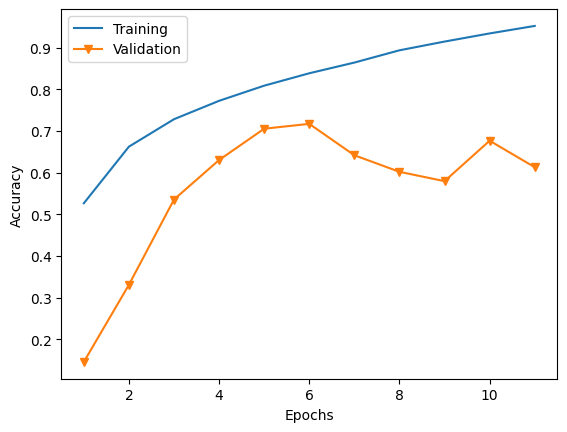

219/219 [==============================] - 1s 4ms/step - loss: 0.8070 - accuracy: 0.7127

---Classes [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


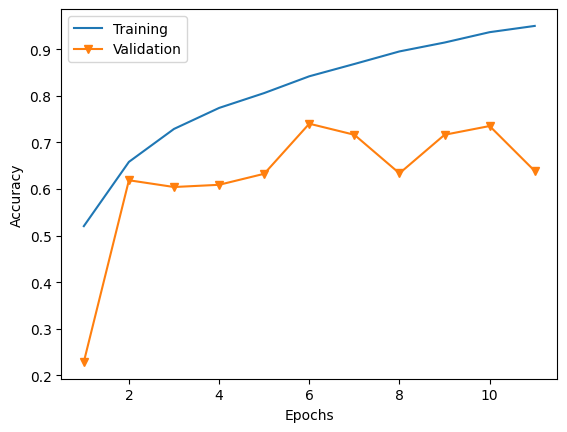

250/250 [==============================] - 1s 4ms/step - loss: 0.7681 - accuracy: 0.7360

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


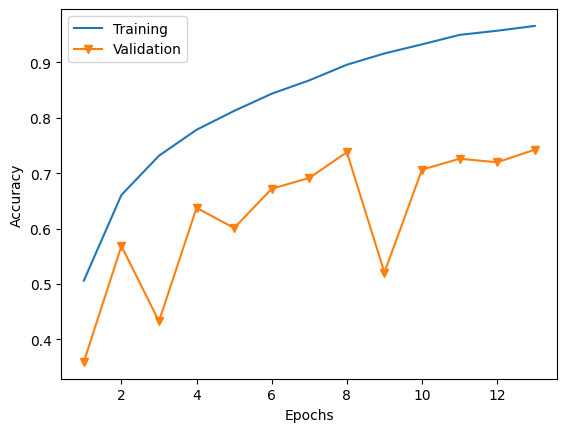

282/282 [==============================] - 1s 4ms/step - loss: 0.8615 - accuracy: 0.7332

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


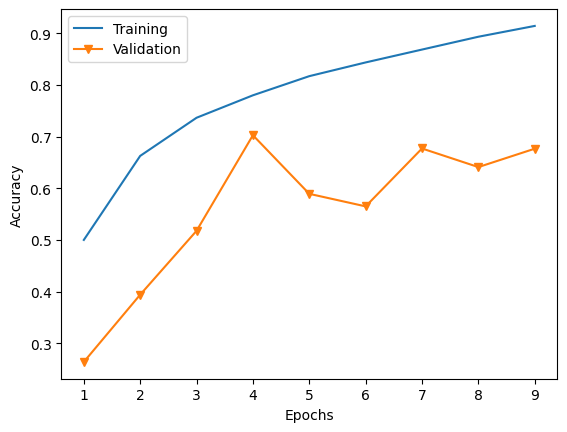

313/313 [==============================] - 1s 4ms/step - loss: 0.8558 - accuracy: 0.7003



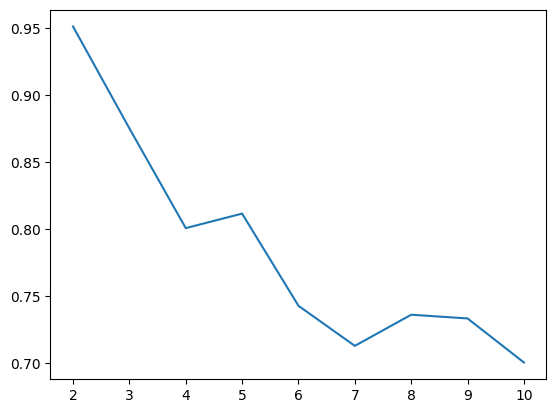

In [15]:
acc_list = []

for i in range(9):
    print(f"---Classes {list(range(i+2))}")

    x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(indices=list(range(0, i+2)), verbose=0)

    new_model = get_model(i+2, model_type="hp-tuned", model_path=TUNED_MODEL_PATH, verbose=0)

    history = new_model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_val, y_val),
        callbacks=get_callbacks(),
        verbose=0,
    ).history

    plot_history(history, indices=[1])

    acc = new_model.evaluate(x_test, y_test)[1]
    acc_list.append(acc)

    print()

plt.plot(list(range(2, 10+1)), acc_list)
plt.show()

# Continually adding classes to the same model

---Classes [0, 1]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


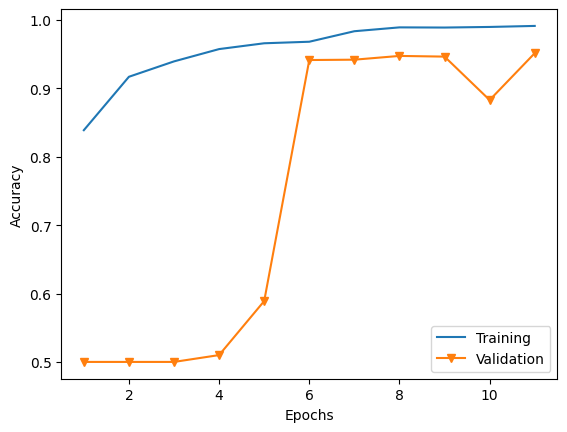

63/63 [==============================] - 0s 4ms/step - loss: 0.1382 - accuracy: 0.9410

---Classes [0, 1, 2]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


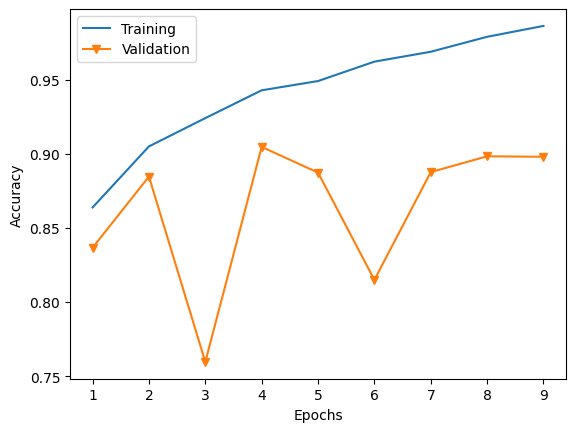

94/94 [==============================] - 0s 4ms/step - loss: 0.2338 - accuracy: 0.9080

---Classes [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


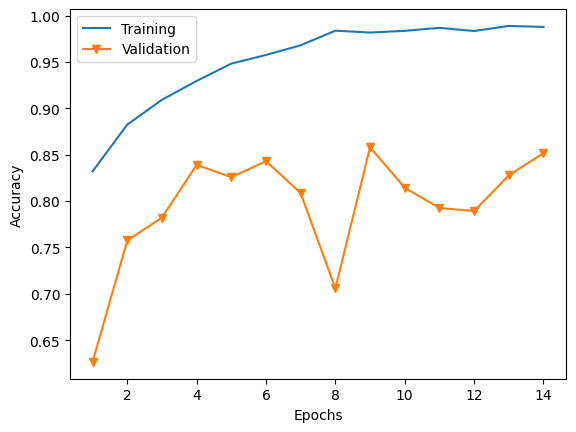

125/125 [==============================] - 1s 4ms/step - loss: 0.5403 - accuracy: 0.8487

---Classes [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


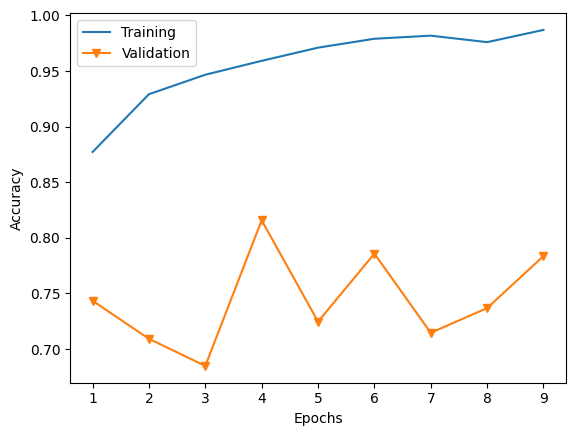

157/157 [==============================] - 1s 4ms/step - loss: 0.6347 - accuracy: 0.8136

---Classes [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


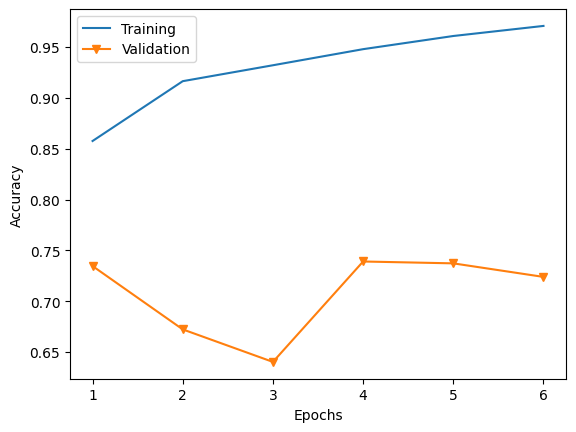

188/188 [==============================] - 1s 4ms/step - loss: 0.8443 - accuracy: 0.7282

---Classes [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


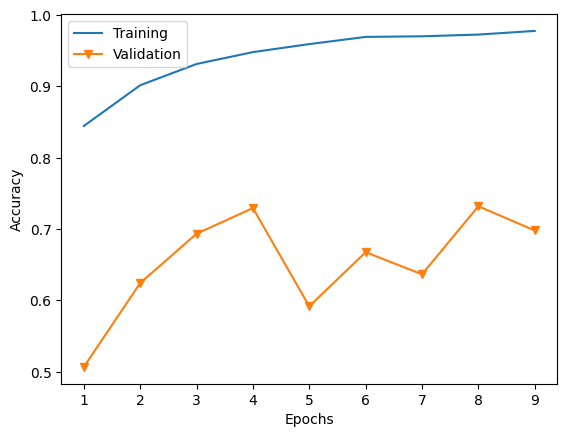

219/219 [==============================] - 1s 4ms/step - loss: 1.0502 - accuracy: 0.7254

---Classes [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


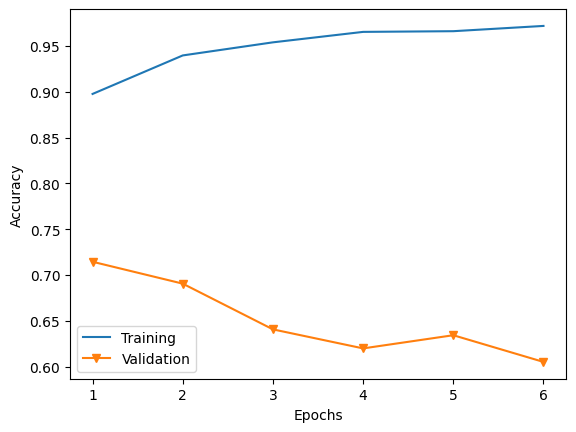

250/250 [==============================] - 1s 4ms/step - loss: 1.0503 - accuracy: 0.7156

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


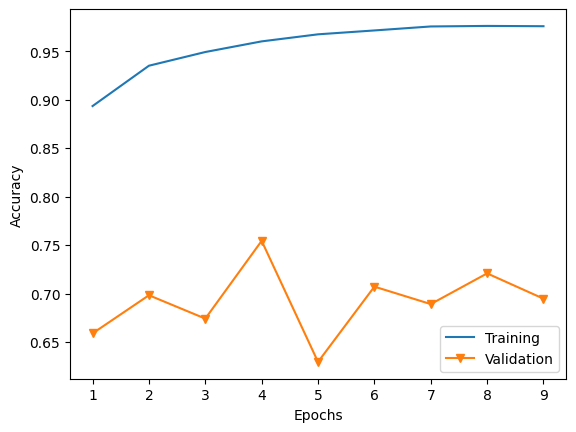

282/282 [==============================] - 1s 4ms/step - loss: 0.9968 - accuracy: 0.7400

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


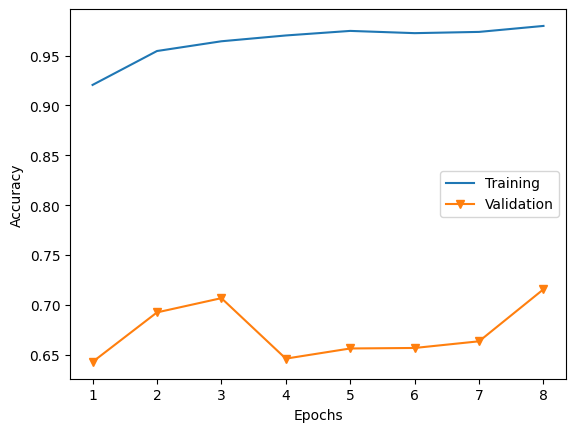

313/313 [==============================] - 1s 4ms/step - loss: 1.4808 - accuracy: 0.7108



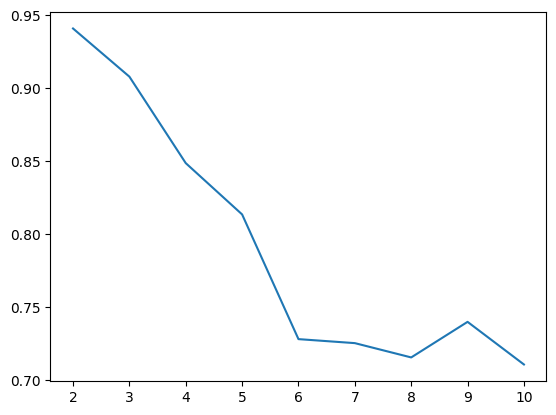

In [16]:
acc_list = []

prev_model = get_model(1, model_type="hp-tuned", model_path=TUNED_MODEL_PATH, verbose=0)
for i in range(9):
    print(f"---Classes {list(range(i+2))}")

    x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(indices=list(range(0, i+2)), verbose=0)

    new_model = get_model(i+2, model_type="hp-tuned", model_path=TUNED_MODEL_PATH, verbose=0)
    copy_model(prev_model, new_model)

    history = new_model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_val, y_val),
        callbacks=get_callbacks(),
        verbose=0,
    ).history

    plot_history(history, indices=[1])

    acc = new_model.evaluate(x_test, y_test)[1]
    acc_list.append(acc)

    prev_model = new_model
    print()

plt.plot(list(range(2, 10+1)), acc_list)
plt.show()

# Continually adding classes to the same model without the previous data

---Classes [0, 1]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


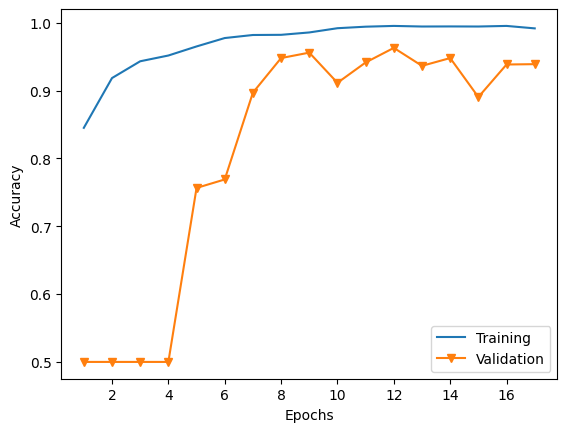

63/63 [==============================] - 0s 4ms/step - loss: 0.1215 - accuracy: 0.9635

---Classes [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


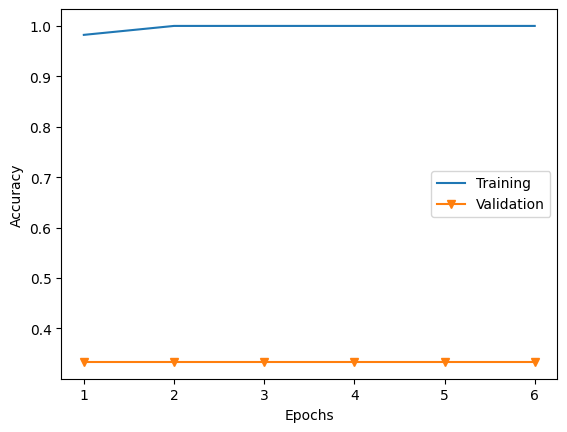

94/94 [==============================] - 0s 4ms/step - loss: 22.8895 - accuracy: 0.3333

---Classes [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


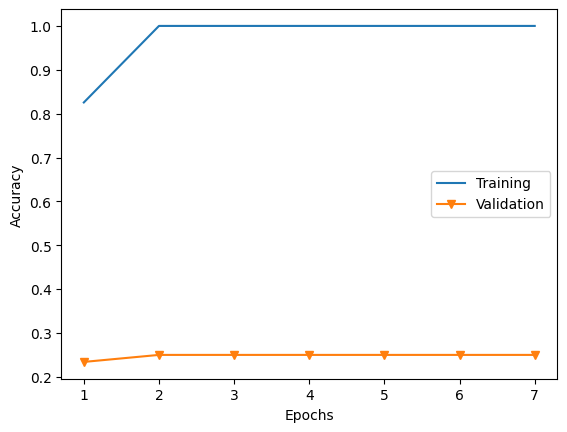

125/125 [==============================] - 1s 4ms/step - loss: 73.9202 - accuracy: 0.2500

---Classes [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


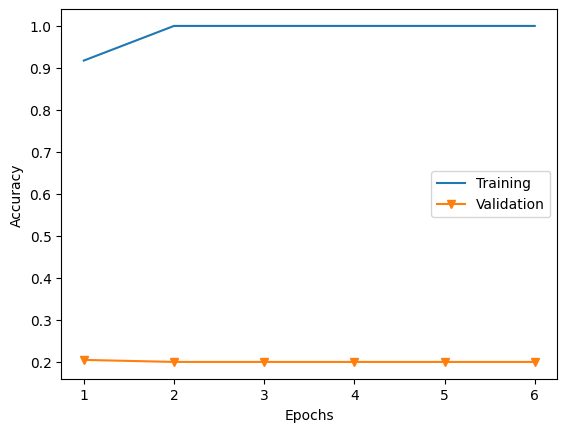

157/157 [==============================] - 1s 4ms/step - loss: 237.1052 - accuracy: 0.2026

---Classes [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


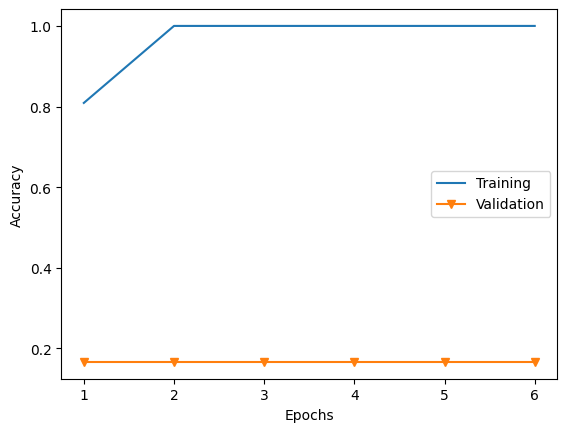

188/188 [==============================] - 1s 4ms/step - loss: 9.2885 - accuracy: 0.1667

---Classes [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


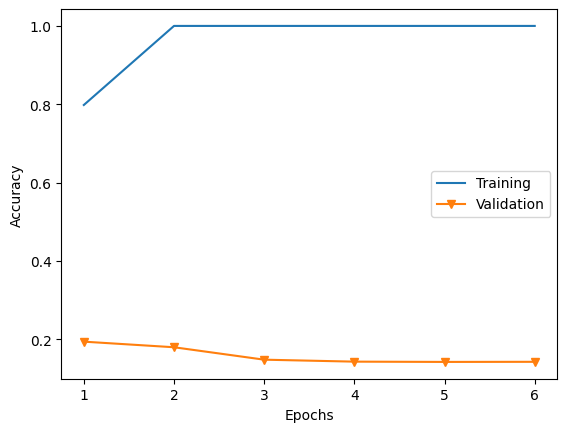

219/219 [==============================] - 1s 4ms/step - loss: 40.4356 - accuracy: 0.1983

---Classes [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


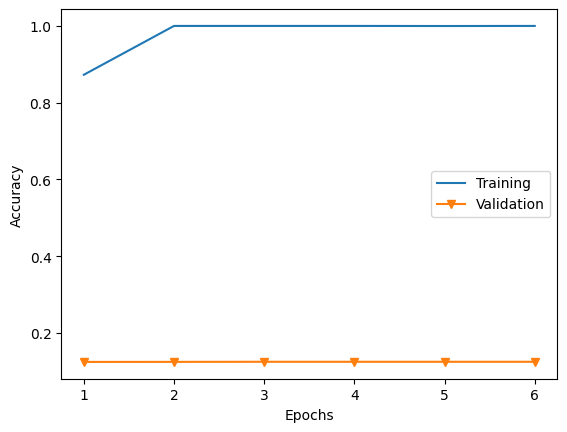

250/250 [==============================] - 1s 4ms/step - loss: 12.7625 - accuracy: 0.1246

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


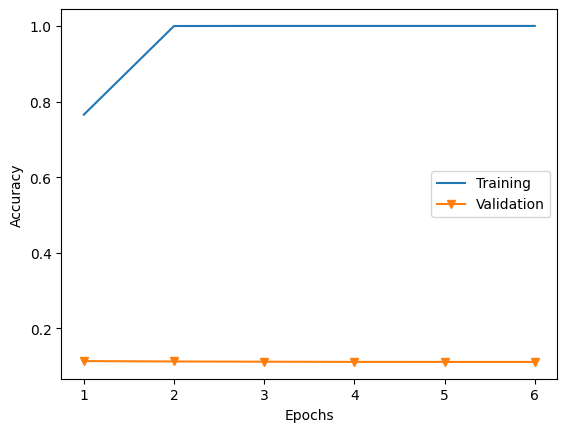

282/282 [==============================] - 1s 4ms/step - loss: 12.2630 - accuracy: 0.1127

---Classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


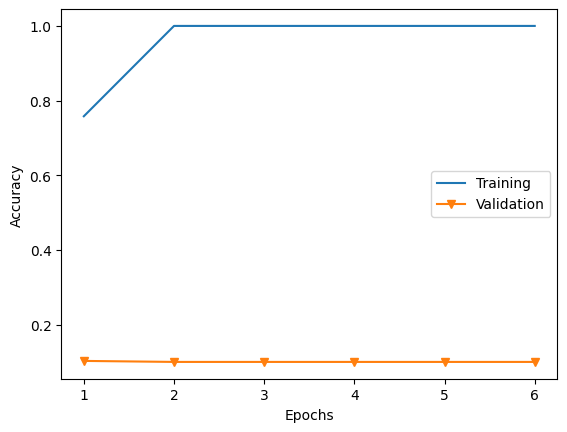

313/313 [==============================] - 1s 4ms/step - loss: 14.0256 - accuracy: 0.1032



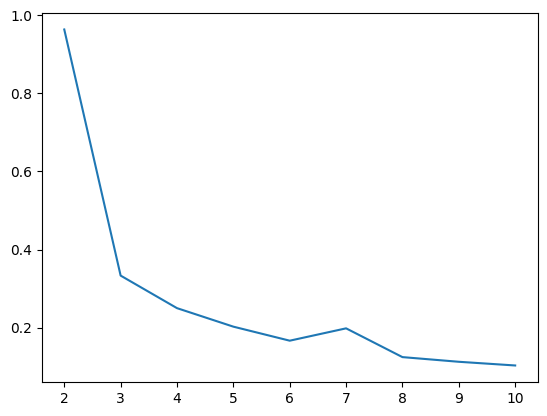

In [17]:
acc_list = []

prev_model = get_model(1, model_type="hp-tuned", model_path=TUNED_MODEL_PATH, verbose=0)
for i in range(9):
    print(f"---Classes {list(range(i+2))}")

    *_, x_val, y_val, x_test, y_test = load_cifar10(indices=list(range(0, i+2)), verbose=0)
    if i == 0:
        x_train, y_train, *_ = load_cifar10(indices=[i, i+1], verbose=0)
    else:
        x_train, y_train, *_ = load_cifar10(indices=[i+1], verbose=0)

    new_model = get_model(i+2, model_type="hp-tuned", model_path=TUNED_MODEL_PATH, verbose=0)
    copy_model(prev_model, new_model)

    history = new_model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_val, y_val),
        callbacks=get_callbacks(),
        verbose=0,
    ).history

    plot_history(history, indices=[1])

    acc = new_model.evaluate(x_test, y_test)[1]
    acc_list.append(acc)

    prev_model = new_model
    print()

plt.plot(list(range(2, 10+1)), acc_list)
plt.show()